In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\vishw\OneDrive\Desktop\newdataset\cs-training.csv")
print(df.shape)
df.head()

(150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
print("Shape after drop:", df.shape)
print("Columns:", df.columns.tolist())
df.info()
df.describe()

Shape after drop: (150000, 11)
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   Number

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [3]:
#class imbalance
#0 = this person paid their loan fine. No serious trouble.
#1 = this person missed payments by 90+ days within 2 years. The bank considers this a default.
print("Count:")
print(df["SeriousDlqin2yrs"].value_counts())
print("\nPercentage:")
print(df["SeriousDlqin2yrs"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Count:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Percentage:
SeriousDlqin2yrs
0    93.32%
1     6.68%
Name: proportion, dtype: object


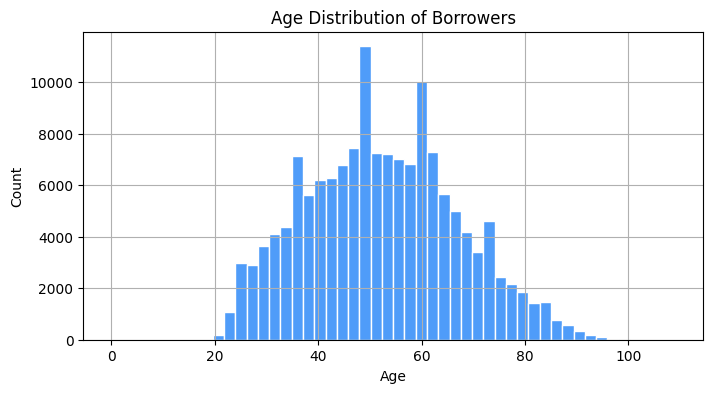

Min age: 0
Max age: 109


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
df["age"].hist(bins=50, color="#4f9cf9", edgecolor="white")
plt.title("Age Distribution of Borrowers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
print("Min age:", df["age"].min())
print("Max age:", df["age"].max())#aged 0 — that's a data error

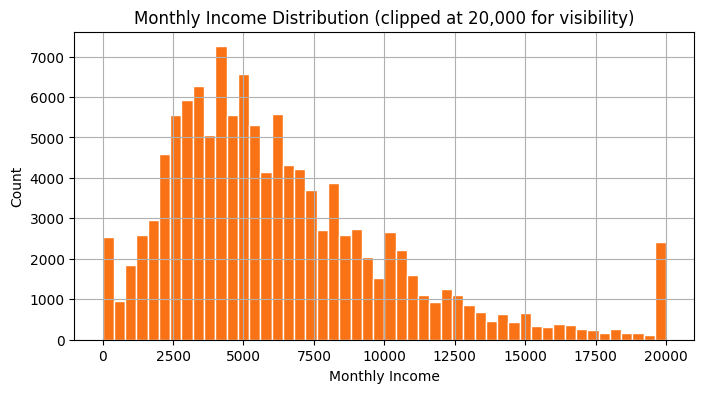

In [5]:
plt.figure(figsize=(8, 4))
df["MonthlyIncome"].dropna().clip(upper=20000).hist(bins=50, color="#f97316", edgecolor="white")
plt.title("Monthly Income Distribution (clipped at 20,000 for visibility)")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.show()

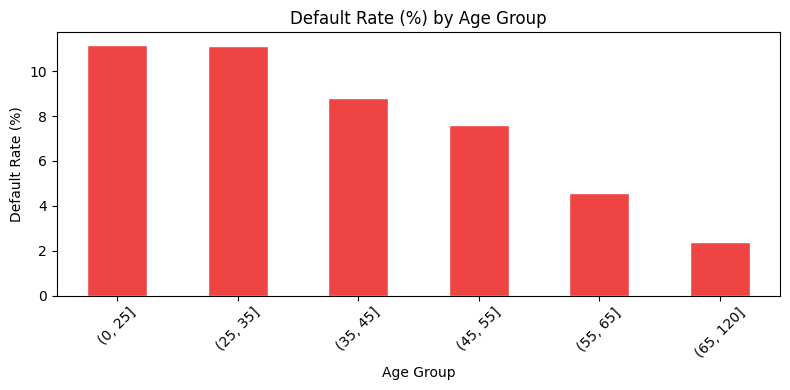

In [6]:
df["age_group"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 120])
default_by_age = df.groupby("age_group", observed=True)["SeriousDlqin2yrs"].mean().mul(100).round(2)
plt.figure(figsize=(8, 4))
default_by_age.plot(kind="bar", color="#ef4444", edgecolor="white")
plt.title("Default Rate (%) by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Clean up temp column
df.drop(columns=["age_group"], inplace=True)

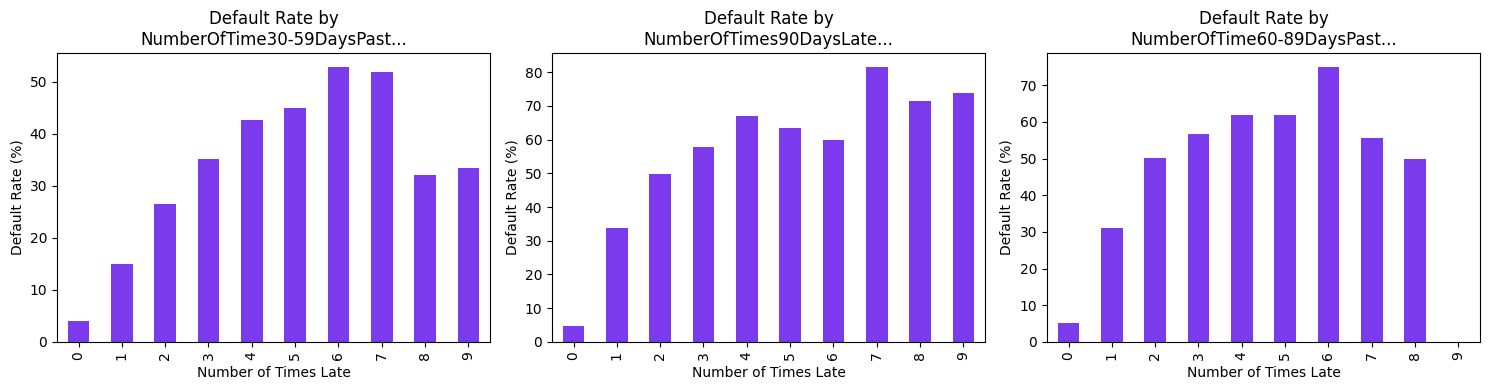

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

for ax, col in zip(axes, late_cols):
    df.groupby(col)["SeriousDlqin2yrs"].mean().head(10).mul(100).plot(kind="bar", ax=ax, color="#7c3aed")
    ax.set_title(f"Default Rate by\n{col[:25]}...")
    ax.set_ylabel("Default Rate (%)")
    ax.set_xlabel("Number of Times Late")

plt.tight_layout()
plt.show()

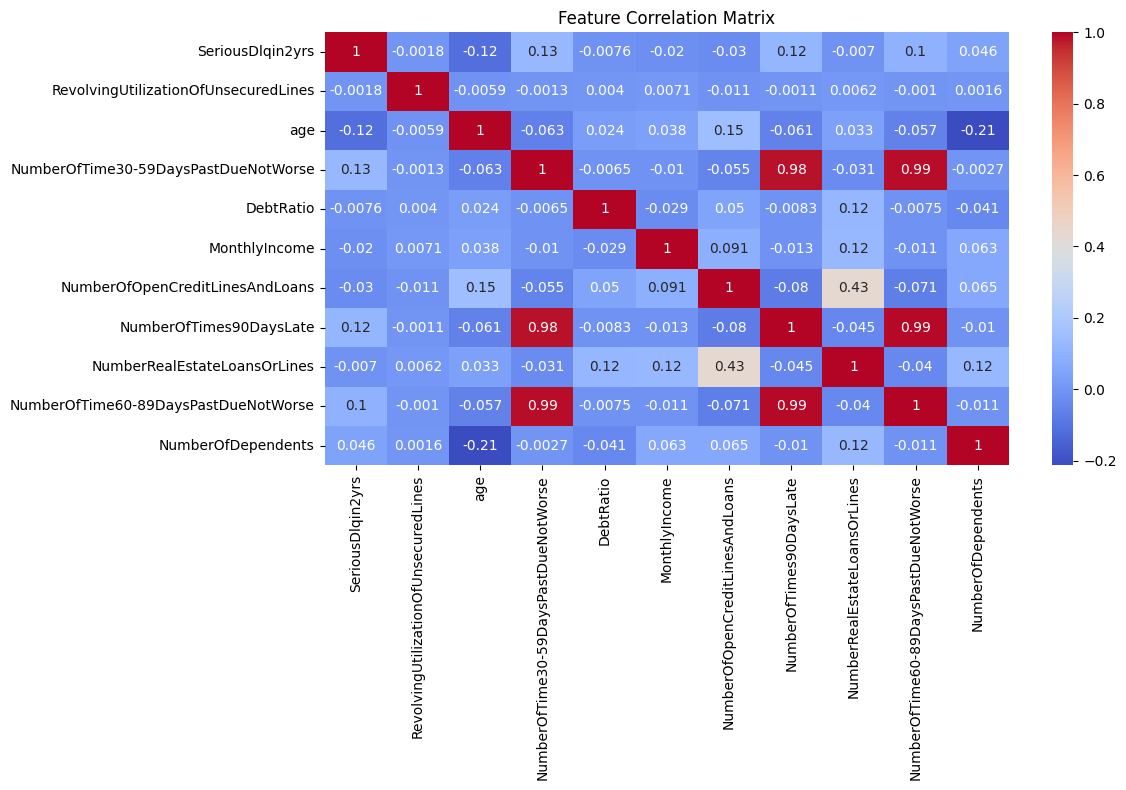

In [8]:
import numpy as np
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

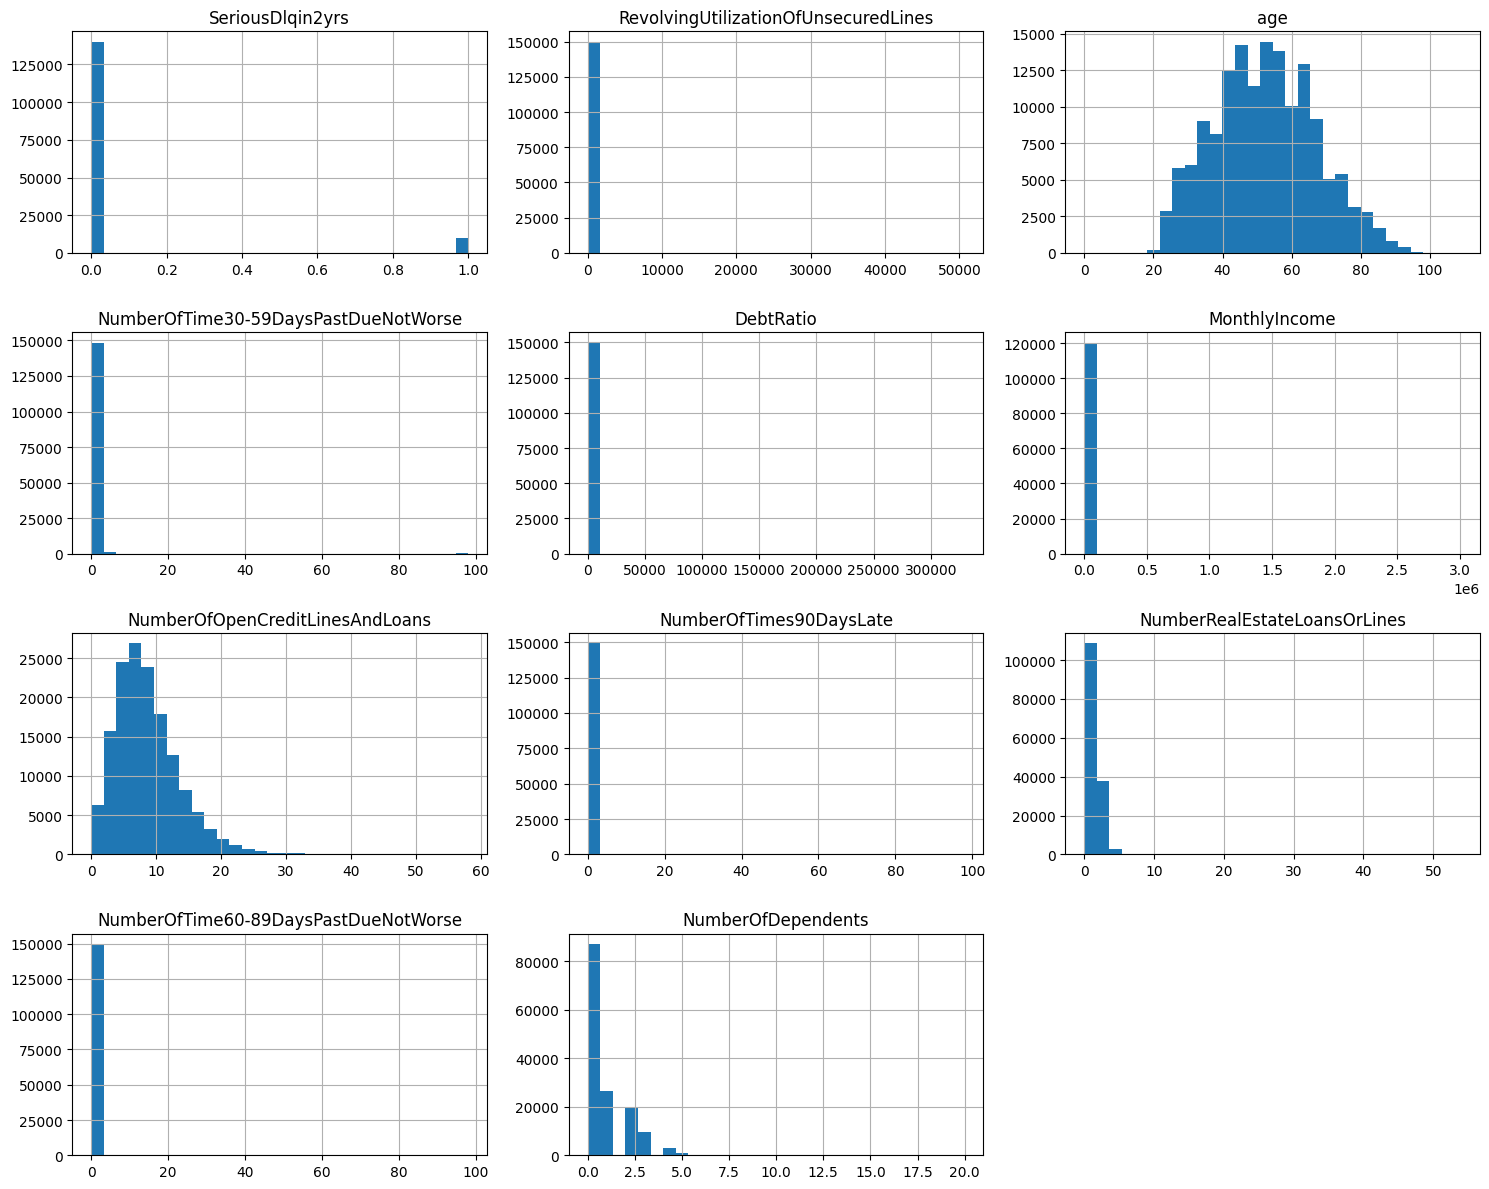

outlier detection


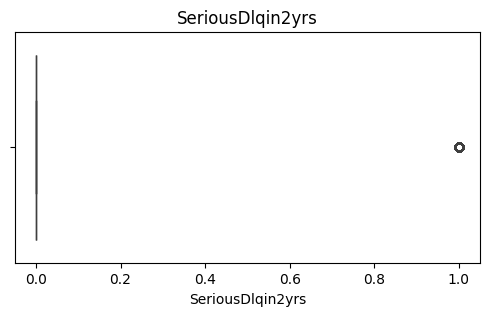

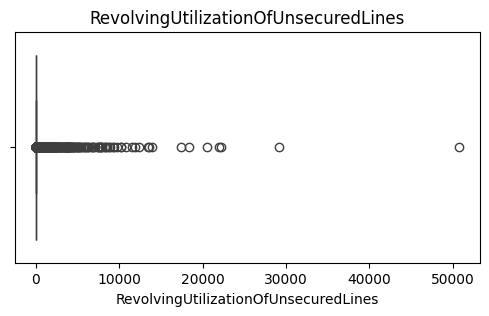

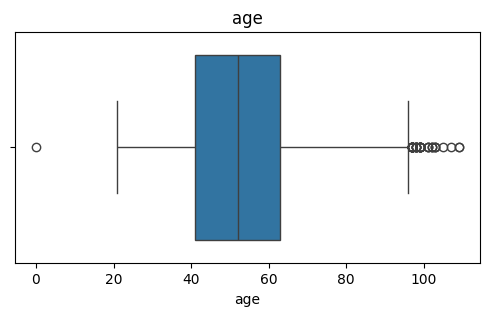

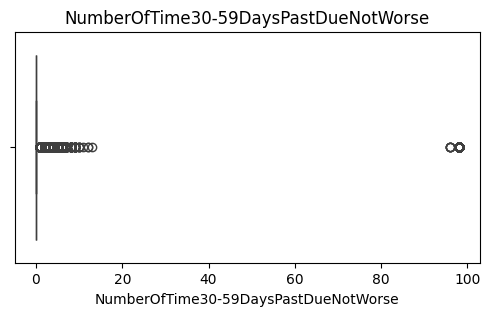

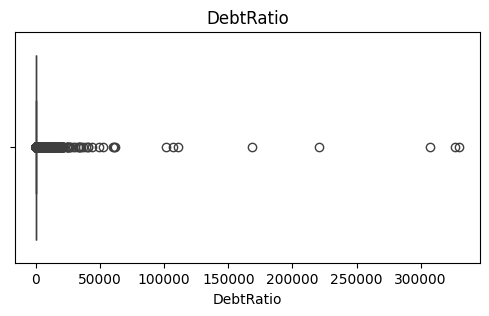

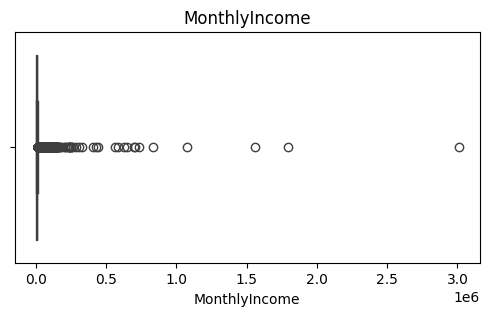

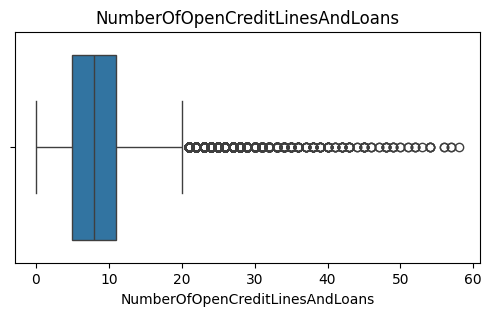

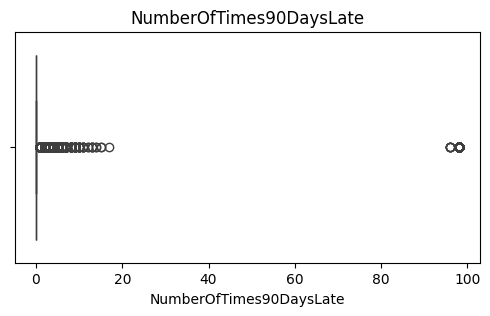

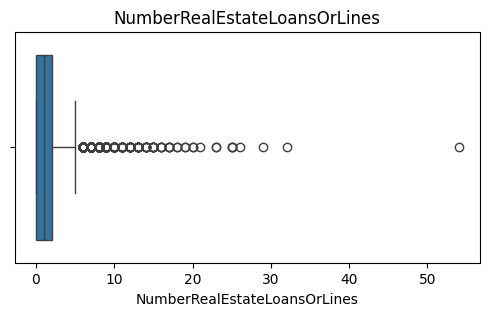

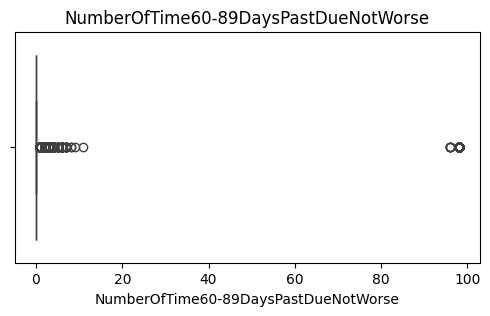

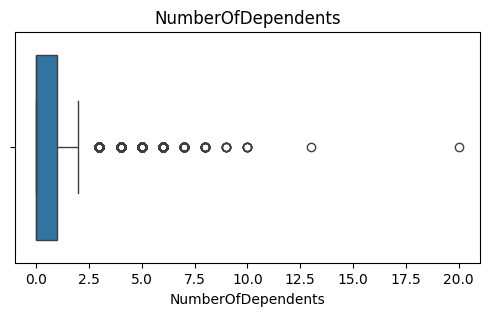

In [9]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()
#Outlier detection
print("outlier detection")
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import mlflow
import mlflow.sklearn
print("All imports done")

All imports done


In [11]:
df = pd.read_csv(r"C:\Users\vishw\OneDrive\Desktop\newdataset\cs-training.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
print("Shape:", df.shape)
df.head(3)

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [12]:
# 1. Remove age errors (for eg 0 years old)
df = df[df["age"] >= 18]
# 2. Fill missing MonthlyIncome with median
income_median = df["MonthlyIncome"].median()
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(income_median)
# 3. Fill missing NumberOfDependents with median
dep_median = df["NumberOfDependents"].median()
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(dep_median)
# 4. Clip extreme outliers
df["DebtRatio"] = df["DebtRatio"].clip(upper=df["DebtRatio"].quantile(0.99))
df["MonthlyIncome"] = df["MonthlyIncome"].clip(upper=df["MonthlyIncome"].quantile(0.99))
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1.0)
# Verify no nulls remain
print("Nulls remaining:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Nulls remaining: 0
Shape after cleaning: (149999, 11)


In [13]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        #93/7 ratio in both splits
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

Features shape: (149999, 10)
Target shape: (149999,)

Feature columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Train size: (119999, 10)
Test size: (30000, 10)

Target distribution in train:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64


In [14]:
# All columns are numerical in this dataset
numerical_cols = X.columns.tolist()
print("Numerical columns:", numerical_cols)
# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols)
])
# Building full pipeline with RandomForest as first model
pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",   # handles the 93/7 imbalance
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipeline built successfully!")
print(pipeline_rf)

Numerical columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Pipeline built successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEstateLoansOrLines',
  

In [17]:
import mlflow
import mlflow.sklearn

# This tells MLflow in Jupyter to connect to the running UI server
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("loans-default-prediction")

with mlflow.start_run(run_name="RandomForest-v1"):

    # Train
    pipeline_rf.fit(X_train, y_train)

    # Predict
    y_pred = pipeline_rf.predict(X_test)
    y_prob = pipeline_rf.predict_proba(X_test)[:, 1]

    # Metrics
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    # Log to MLflow
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)
    mlflow.log_metric("precision", pre)
    mlflow.log_metric("recall", rec)

    mlflow.sklearn.log_model(pipeline_rf, "model")

    print("=== Random Forest Results ===")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"Precision : {pre:.4f}")
    print(f"Recall    : {rec:.4f}")

2026/06/04 21:34:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 21:34:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Random Forest Results ===
F1 Score  : 0.2457
ROC-AUC   : 0.8384
Precision : 0.5445
Recall    : 0.1586
🏃 View run RandomForest-v1 at: http://localhost:5000/#/experiments/2/runs/8aebae6ce5a04ecb9f0aabdae75815e2
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [18]:
pipeline_lr = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ("num", StandardScaler(), numerical_cols)
    ])),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

with mlflow.start_run(run_name="LogisticRegression-v1"):

    pipeline_lr.fit(X_train, y_train)

    y_pred = pipeline_lr.predict(X_test)
    y_prob = pipeline_lr.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)
    mlflow.log_metric("precision", pre)
    mlflow.log_metric("recall", rec)

    mlflow.sklearn.log_model(pipeline_lr, "model")

    print("=== Logistic Regression Results ===")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"Precision : {pre:.4f}")
    print(f"Recall    : {rec:.4f}")

2026/06/04 21:35:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 21:35:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Logistic Regression Results ===
F1 Score  : 0.2964
ROC-AUC   : 0.8339
Precision : 0.1846
Recall    : 0.7511
🏃 View run LogisticRegression-v1 at: http://localhost:5000/#/experiments/2/runs/d22a91c61ad948c09b8fb5ff85680c87
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [ ]:
pipeline_gb = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ("num", StandardScaler(), numerical_cols)
    ])),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

with mlflow.start_run(run_name="GradientBoosting-v1"):

    pipeline_gb.fit(X_train, y_train)  
    y_pred = pipeline_gb.predict(X_test)
    y_prob = pipeline_gb.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    mlflow.log_param("model", "GradientBoosting")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)
    mlflow.log_metric("precision", pre)
    mlflow.log_metric("recall", rec)

    mlflow.sklearn.log_model(pipeline_gb, "model")

    print("=== Gradient Boosting Results ===")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"Precision : {pre:.4f}")
    print(f"Recall    : {rec:.4f}")

2026/06/04 21:36:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 21:36:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
results = {
    "RandomForest": pipeline_rf,
    "LogisticRegression": pipeline_lr,
    "GradientBoosting": pipeline_gb,
}

print(f"{'Model':<25} {'ROC-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 70)

scores = {}
for name, pipeline in results.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    scores[name] = auc
    print(f"{name:<25} {auc:>10.4f} {f1:>10.4f} {pre:>10.4f} {rec:>10.4f}")

best_model_name = max(scores, key=scores.get)
print(f"\nBest model by ROC-AUC: {best_model_name}")

In [ ]:
best_pipeline = results[best_model_name]

y_pred_best = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Default", "Default"]))

In [ ]:
# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save best pipeline
joblib.dump(best_pipeline, "../models/best_pipeline.pkl")

print(f"Saved: {best_model_name} → ../models/best_pipeline.pkl")

# Verify it loads correctly
loaded = joblib.load("../models/best_pipeline.pkl")
test_pred = loaded.predict(X_test.head(5))
print("Quick test predictions:", test_pred)
print("Model saved and verified successfully!")

In [ ]:
import sklearn
print(sklearn.__version__)